In [ ]:
# Langchain import
from langchain.prompts import PromptTemplate, ChatPromptTemplate
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_chroma import Chroma
# from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langgraph.graph import START, StateGraph

# Transformer import
# from sentence_transformers import CrossEncoder
# from transformers import AutoModelForSequenceClassification
# import py_vncorenlp

# Common import
from typing import List, TypedDict, Any

# System import
import sys
sys.path.insert(0, "..")

# Local import
from utils.dto import QueryQuestion
from components.query_translation import query_translation
from components.query_analysis import query_analysis
from components.retriever import retrieve_and_rerank

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Enviroment import 
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path=".env")
# Load environment variables
LANGSMITH_TRACING = os.getenv("LANGSMITH_TRACING")
LANGSMITH_ENDPOINT = os.getenv("LANGSMITH_ENDPOINT")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")
LANGSMITH_PROJECT = os.getenv("LANGSMITH_PROJECT")

OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL")
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL")
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL")
RERANK_MODEL = os.getenv("RERANK_MODEL")
# RERANK_MAX_LENGTH = int(os.getenv("RERANK_MAX_LENGTH"))

VECTOR_STORE_COLLECTION = os.getenv("VECTOR_STORE_COLLECTION")
VECTOR_STORE_HOST = os.getenv("VECTOR_STORE_HOST")
VECTOR_STORE_PORT = int(os.getenv("VECTOR_STORE_PORT"))

In [3]:
# Ollama model initialization
llm = ChatOllama(model=OLLAMA_MODEL, base_url=OLLAMA_BASE_URL)
print(f"LLM model loaded: {llm.model}")

# Embedding model
# embedding_model = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)
embedding_model = OllamaEmbeddings(model=EMBEDDING_MODEL, base_url=OLLAMA_BASE_URL)
print(f"Embedding model loaded: {embedding_model.model}")

# Reranker model
# reranker_model = CrossEncoder(RERANK_MODEL, max_length=RERANK_MAX_LENGTH)
reranker_model = AutoModelForSequenceClassification.from_pretrained(
    RERANK_MODEL,
    torch_dtype="auto",
    trust_remote_code=True,
    use_flash_attn=False,
)
reranker_model.to('cpu')
# reranker_model = RERANK_MODEL
print(f"Reranker model loaded: {RERANK_MODEL}")

# Vector store initialization
# persist_directory = "./database/all-MiniLM-L6-v2/3000_300"
vector_store = Chroma(
    # persist_directory=persist_directory,
    host=VECTOR_STORE_HOST,
    port=VECTOR_STORE_PORT,
    collection_name=VECTOR_STORE_COLLECTION,
    embedding_function=embedding_model,
)
print(f"Total number of documents in the vector store: {vector_store._collection.count()}")

retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k":5})

LLM model loaded: llama3
Embedding model loaded: bge-m3
Reranker model loaded: jinaai/jina-reranker-v2-base-multilingual
Total number of documents in the vector store: 4099


In [4]:
# py_vncorenlp.download_model(save_dir='/workspace/AI_chatbot/models')
# rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/workspace/AI_chatbot/models')

In [5]:
rag_template = """
Bạn là một luật sư giàu kinh nghiệm với vai trò tư vấn pháp lý cho khách hàng. Hãy trả lời câu hỏi của khách hàng bằng tiếng Việt CHỈ dựa trên các tài liệu đã cung cấp:
{context}
Câu hỏi: {question}
"""
prompt = ChatPromptTemplate.from_template(rag_template)

In [6]:
# Langgraph state definition
class State(TypedDict):
    raw_question: str
    query: List[str]
    structured_query: List[str]
    context: List[tuple[Document, Any]]
    answer: str

In [7]:
# Langgraph node definition
def translation(state: State):
    query = query_translation(state["raw_question"], llm)
    return {"query": query}
    
def analysis(state: State):
    structured_query = query_analysis(state["query"])
    return {"structured_query": structured_query}
    
def retrieve(state: State):
    # retrieved_docs = vector_store.similarity_search(state["structured_query"], k=5)
    retrieved_docs = retrieve_and_rerank(retriever, reranker_model, state["raw_question"], state["structured_query"])
    return {"context": retrieved_docs}

def generate(state: State):
    docs_contents = "\n\n".join(doc[0].page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["raw_question"], "context": docs_contents})
    response = llm.invoke(messages)
    return {"answer": response.content}

In [8]:
graph_builder = StateGraph(State).add_sequence([translation, analysis, retrieve, generate])
graph_builder.add_edge(START, "translation")
graph = graph_builder.compile()

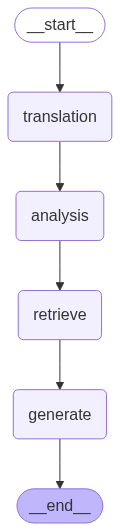

In [9]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
result = graph.invoke({"raw_question": "Các nguyên tắc cơ bản của hôn nhân và gia đình là gì?"})

print("Context:\n" + '\n'.join([f"{num + 1}/ {doc[0].page_content}" for num, doc in enumerate(result['context'])]))
print(f"\n\nAnswer: {result['answer']}")

Context:
1/ QUỐC HỘI CỘNG HÒA XÃ HỘI CHỦ NGHĨA VIỆT NAM Độc lập - Tự do - Hạnh phúc Số: 52/2014/QH13 Hà Nội, ngày 19 tháng 06 năm 2014 LUẬT HÔN NHÂN VÀ GIA ĐÌNH Căn cứ Hiến pháp nước Cộng hòa xã hội chủ nghĩa Việt Nam; Quốc hội ban hành Luật hôn nhân và gia đình. Chương INHỮNG QUY ĐỊNH CHUNG Điều 1. Phạm vi điều chỉnhLuật này quy định chế độ hôn nhân và gia đình; chuẩn mực pháp lý cho cách ứng xử giữa các thành viên gia đình; trách nhiệm của cá nhân, tổ chức, Nhà nước và xã hội trong việc xây dựng, củng cố chế độ hôn nhân và gia đình. Điều 2. Những nguyên tắc cơ bản của chế độ hôn nhân và gia đình1. Hôn nhân tự nguyện, tiến bộ, một vợ một chồng, vợ chồng bình đẳng. 2. Hôn nhân giữa công dân Việt Nam thuộc các dân tộc, tôn giáo, giữa người theo tôn giáo với người không theo tôn giáo, giữa người có tín ngưỡng với người không có tín ngưỡng, giữa công dân Việt Nam với người nước ngoài được tôn trọng và được pháp luật bảo vệ. 3. Xây dựng gia đình ấm no, tiến bộ, hạnh phúc; các thành viên gi

In [11]:
reranker_model.eval()

XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(1026, 768)
      (token_type_embeddings): Embedding(1, 768)
    )
    (emb_drop): Dropout(p=0.1, inplace=False)
    (emb_ln): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (encoder): XLMRobertaEncoder(
      (layers): ModuleList(
        (0-11): 12 x Block(
          (mixer): MHA(
            (Wqkv): LinearResidual(in_features=768, out_features=2304, bias=True)
            (inner_attn): SelfAttention(
              (drop): Dropout(p=0.1, inplace=False)
            )
            (inner_cross_attn): CrossAttention(
              (drop): Dropout(p=0.1, inplace=False)
            )
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (dropout1): Dropout(p=0.1, inplace=False)
          (drop_path1): StochasticDepth(p=0.0, mode=r